# <b> TPC - EXERCÍCIO 4 DA FOLHA 7 </b>

## Física Computacional - PL 2

## 13-12-2021

<hr>

Anabela Sampaio Pereira (a92849) 

Beatriz Sousa Demétrio (a92839)

Carlos Miguel Passos Ferreira (a92846)

### ENUNCIADO:

Os ficheiros $folha7-data4.txt$ e $folha7-data5.txt$ contêm as intensidades sonoras em função do tempo correspondentes a uma nota musical tocada por um piano e um trompete. Calcule e represente os primeiros $10 000$ coeficientes de Fourier, discutindo os resultados obtidos. Há alguma vantagem em usar FFTs neste caso? Sabendo que as ondas sonoras foram gravadas com uma frequência de amostragem de $44,1 kHz$, qual a frequência da nota que foi tocada no piano? E no trompete?

## RESOLUÇÃO:

In [1]:
import math
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import sympy as sp
import random as rd

### Séries de Fourier:


Segundo o matemático francês Joseph Fourier (1768-1830), sabemos que qualquer sinal periódico pode ser decomposto numa soma de ondas sinusóidais puras. Ora, cada sinusóide tem uma frequência que é um múltiplo inteiro da frequência fundamental da onda original. A estes múltiplos denominamos de "harmónicos".

Um sinal $x(t)$ pode ser expresso como uma <b> série trigonométrica de Fourier </b>:

$x(t)$ = $\frac{a_0}{2}$ + $\sum_{k=1}^{∞}[a_k \cdot \cos{(\frac{2\pi}{T} \cdot kt)} + b_k \cdot \sin{(\frac{2\pi}{T} \cdot kt)}]$                              (equação 1)

(a esta equação chamamos de equação síntese)


sendo que:

-  $a_k$ = $\frac{2}{T} \int_{T} x(t) \cdot \cos{(\frac{2\pi}{T} \cdot kt)} dt$ , aonde que $k=0,1,2,...$  (equação 2)

-  $b_k$ = $\frac{2}{T} \int_{T} x(t) \cdot \sin{(\frac{2\pi}{T} \cdot kt)} dt$ , aonde que $k=1,2,...$ (equação 3)

(a estas duas equações chamamos de equações de análise ou de coeficientes de Fourier)

- $T$ = $\frac{2\pi}{w_0}$, que é o período fundamental do sinal $x(t)$.
Este período fundamental é, por definição, o período de todas as amostras recolhidas, ou seja, entre a primeira e última amostra.

Se repararmos atentamente verificamos que $k$ é apenas igual a $0$ na equação de $a_k$. Por isso, podemos dizer que, de certa forma, $a_0$ representa um valor médio do sinal x(t) no intervalo de período $T$.

Também existe a <b> série exponencial/complexa de Fourier </b>, que é aplicada quando o sinal periódico contínuo tem como valores complexos, que têm parte real e imaginária. Mas já neste caso o sinal pode ser também descrito da seguinte forma:

$x(t)$ = $\sum_{k=-∞}^{∞} c_k \cdot e^{i \cdot \frac{2\pi}{T} \cdot kt}$    (equação 4)

sendo que:

$c_k$ = $\frac{1}{T} \int_{T} x(t) \cdot e^{-i \cdot \frac{2\pi}{T} \cdot kt} dt$ , onde se tem que $k$ = $0, \pm 1, \pm 2, ... $   (equação 5)

Mas se atentarmos ao que pede o exercício, verificamos que este pede 2 coisas:

-  pede para calcular e representar os 10000 coeficientes de Fourier e discutir os resultados obtidos;

-  sabendo a frequência de amostragem, que é igual a $44,1 kHz$, pede para se calcular as frequências das notas tocadas pelo piano e pelo trompete (estas notas são dadas pelos datas 4 e 5, respetivamente).

Portanto, nós estamos a falar em frequências e não em tempos. Daí que entra o termo <b> TRANSFORMADA DE FOURIER </b>. Enquanto que a série de Fourier, que vimos em cima, usamos para representar uma função periódica por uma soma de exponenciais complexas ou de senos e cossenos, a transformada de Fourier iremos utilizar para representar uma função geral, que pode ou não ser periódica, por uma superposição contínua ou uma integral de exponenciais complexas. A transformada de Fourier explica exatamente quais frequências estão no sinal original de uma forma de onda qualquer.

### Transformada de Fourier

Dado a série de Fourier, a sua transformada pode ser obtida de 2 maneiras muito importantes:
-  os limites de integração são finitos, tornando, assim, o período da função ilimitado;
-  a frequência $w$ aceita todos ps valores reais.

Para sequências de valores que estão espaçados uniformemente, a Transformada Discreta de Fourier (ou DFT,se escrevermos em inglês) é definida da seguinte forma:

$X_k$ = $\sum_{n=1}^{N-1} x_n e^{-i \cdot \frac{2\pi}{N} \cdot kn}$  (equação 6)

onde temos que:

-  $N$ é o número de amostras;
-  $n$ é a n-ésima amostra (isto é, a ordem do harmônico -> representa o número de vezes que a frequência desse mesmo harmônico é maior que o componente básico);
-  $k$ é a frequência (de $0 Hz$ a $N-1 Hz$);
-  $X_k$ são os números complexos resultantes da DFT (a sua amplitude e fase);
-  $x_n$ são números complexos, com parte imaginária igual a zero ou não, do valor do sinal no instante $n$.

Já a representação da transformada inversa de Fourier em frequências é dada da seguinte forma:

$x_n$ = $\frac{1}{N} \cdot \sum_{k=0}^{N-1} X_k \cdot e^{i\cdot 2\pi \cdot \frac{k}{N} \cdot n}$   (equação 7)

Além desta transformada temos a <b> TRANSFORMADA RÁPIDA DE FOURIER </b>, que tem como algoritmo a divisão recursiva do DFT em DFTs mais pequenos, diminuindo assim drasticamente o tempo de computação necessário, sendo por isso uma forma muito mais rápida e eficiente de calcular a transformada de Fourier.

Primeiro vamos começar por analisar os ficheiros correspondentes ao piano: $folha7-data4.txt$

Text(0.5, 1.0, 'Piano')

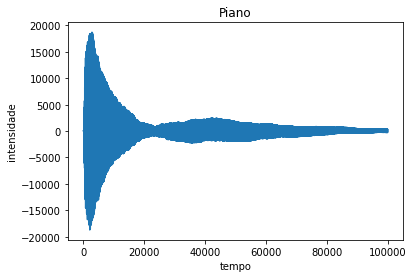

In [2]:
# pegando nos valores para o piano, queremos de seguida obter o gráfico correspondente:
from numpy import loadtxt
data4=loadtxt("folha7-data4.txt")   # aqui temos a importação dos ficheiros data 

plt.xlabel('tempo')    # definição do eixo dos x
plt.ylabel('intensidade')   # definição do eixo dos y
plt.plot(data4)     # definição dos valores do data para colocar no gráfico (em vermelho)
plt.title('Piano')

Wall time: 17.3 s


Text(0.5, 1.0, 'Transformada de Fourier - Piano')

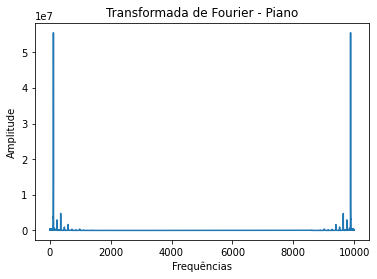

In [3]:
%%time
# Basicamente, na construção deste código utilizamos a equação 6 e escrevemos em python. Obtivemos o seguinte:
def DFT_slow(x):
    x = np.asarray(x, dtype=float)         # este x corresponde ao valor do sinal no instante n (o np.asarray vai converter a entrada x numa matriz de valores do tipo float)
    N = x.shape[0]            # N é o número de amostras utilizadas (a função .shape[0] vai nos dar o número de linhas da entrada x)
    n = np.arange(N)          # este n é a ordem do harmônico (np.arange(N) vai retornar um array de valores espaçados entre 0 e N-1) -> faz o papel do somatório
    k = n.reshape((N,1))      # frequência
    M = np.exp(-2j * np.pi * k * n / N)    # é o exponencial que está dentro do somatório
    
    return np.dot(M,x)         

# De forma a obter os primeiros 10000 elementos precisamos de reduzir o tamanho do data4

#index = range(10000,100000,1)
#data4m = np.delete(data4,index)
                                    # as duas linhas acima e a linha de código a seguir são duas formas de obter os primeiros 10000 elementos
data4m = data4[0:10000]

# Aplicação da função DFT_slow no data4 já reduzido
y = abs(DFT_slow(data4m))

# Construção do gráfico da transformada do data4 reduzido
plt.xlabel('Frequências')
plt.ylabel('Amplitude')
plt.plot(y)
plt.title('Transformada de Fourier - Piano')

In [4]:
# Para calcular a transformada de Fourier, iremos agora utilizar outro método mais rápido e mais eficiente: FFT

def FFT(x):
    x = np.asarray(x,dtype=float)  # este x corresponde ao valor do sinal no instante n (o np.asarray vai converter a entrada x numa matriz de valores do tipo float)
    N = x.shape[0]                 # N é o número de amostras utilizadas (a função .shape[0] vai nos dar o número de linhas da entrada x)

    if N % 2 > 0:          # se o resto da divisão de N (que é o número de amostras) com 2 for maior que 0, isto é, não é divisível por 2
        raise ValueError('size of x must be a power of 2')    # se N não for divisível por dois vai aparecer este erro
    elif N <= 32:             # se o N for divisível por 2 e menor ou igual a 32 
        return DFT_slow(x)    # vai se aplicar a função DFT_slow ao x
    else:        # se as duas condições anteriores não se verificarem vamos fazer o seguinte
        X_even = FFT(x[::2])     # vai aplicar a função FFT ao valores pertencentes a x que estão nos índices pares (começando no índice  0)
        X_odd = FFT(x[1::2])     # vai aplicar a função FFT ao valores pertencentes a x que estão nos índices ímpares (começando no índice 1)
        factor = np.exp(-2j*np.pi*np.arange(N)/N)     # é exponencial 
        return np.concatenate([X_even + factor[:N / 2] * X_odd, X_even + factor[N / 2:] * X_odd])  # aqui temos a junção de vários arrays, que foram especificados durante a função

# Aplicação da função FFT no data4
z = FFT(data4)

# Construção do gráfico da transformada do data4
plt.xlabel('Frequências')
plt.ylabel('Amplitude')
plt.plot(z)

# Este código está a dar erro, portanto decidimos proceder ao uso da função predefinida para o cálculo das FFTs


ValueError: size of x must be a power of 2

Wall time: 46.4 ms


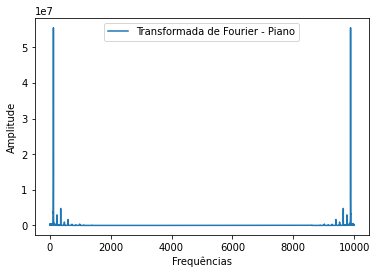

In [ ]:
%%time
z = abs (np.fft.fft(data4m))

# Construção do gráfico da transformada do data4
plt.xlabel('Frequências')
plt.ylabel('Amplitude')
plt.plot(z,label='Transformada de Fourier - Piano')
plt.legend()

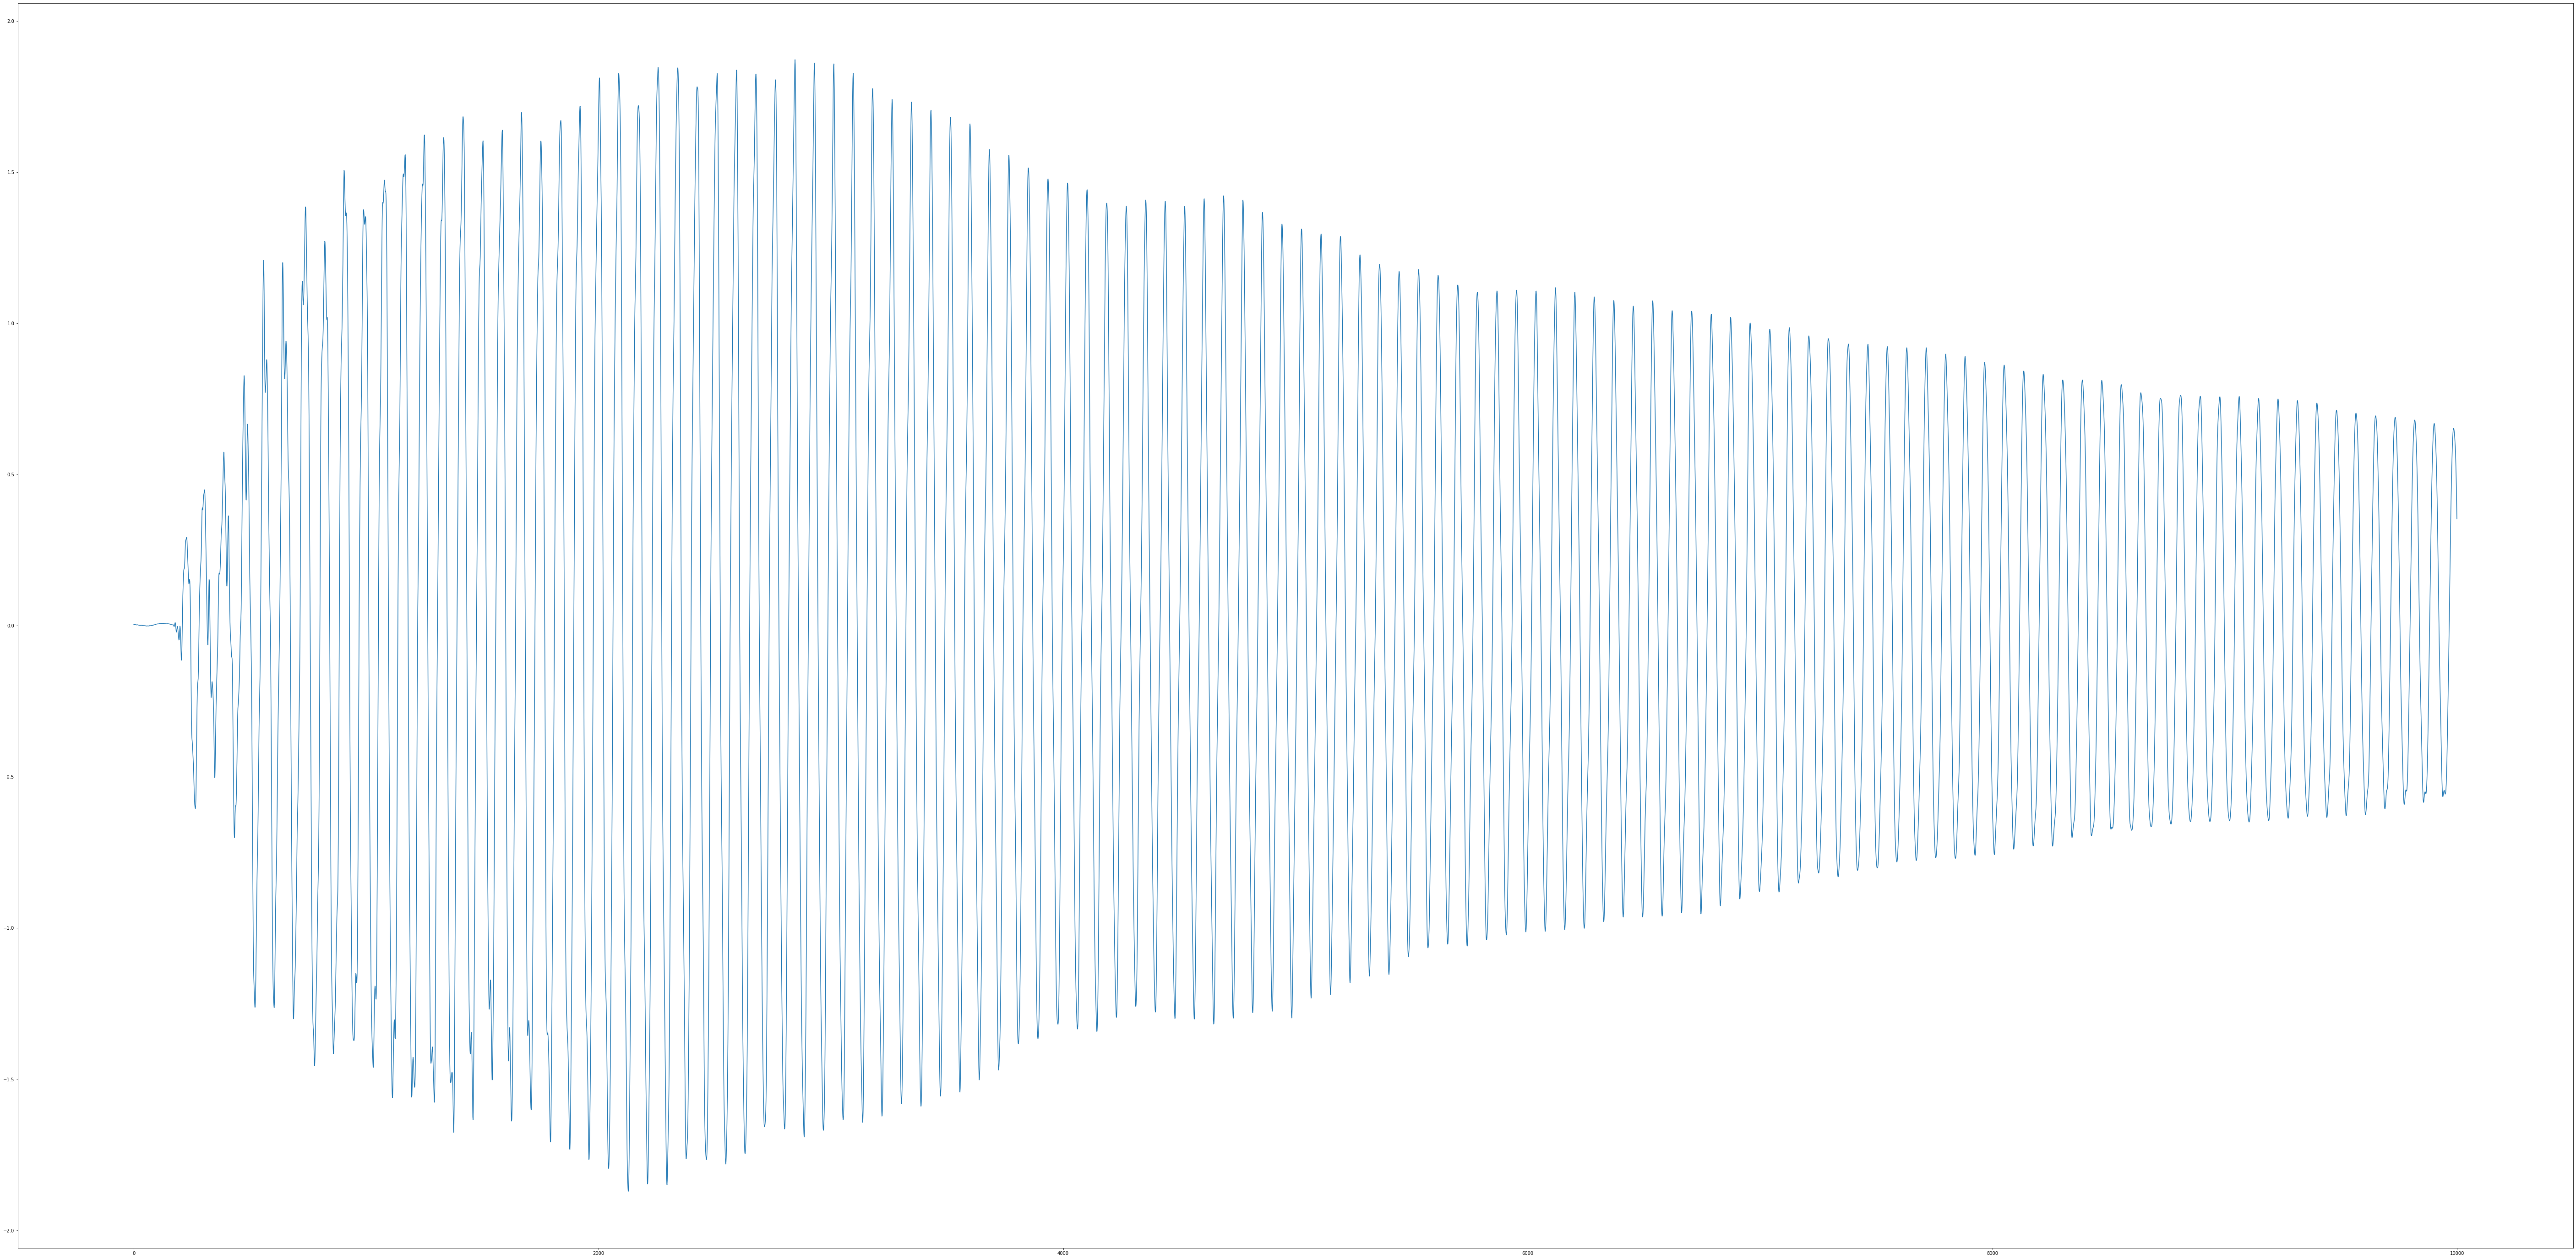

In [ ]:
# calculando agora os coeficientes da série de Fourier correspondente vamos ter o seguinte:
y1=np.fft.rfft(data4m)/10000
plt.figure(figsize=[100,50])
plt.plot(np.fft.irfft(y1))

Por fim iremos repetir a analise dos ficheiros correspondentes ao trompete: $folha7-data5.txt$

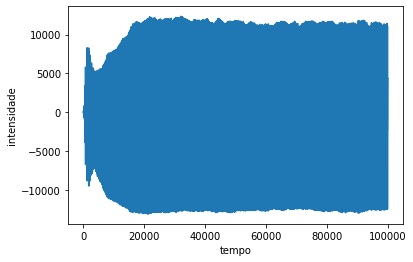

In [ ]:
# pegando nos valores para o trompete temos o seguinte gráfico:

from numpy import loadtxt
data5=loadtxt("folha7-data5.txt")     # aqui temos a importação dos ficheiros data 

plt.xlabel('tempo')      # definição do eixo dos x
plt.ylabel('intensidade')     # definição do eixo dos y
plt.plot(data5)           # definição dos valores do data para colocar no gráfico

Wall time: 7.84 s


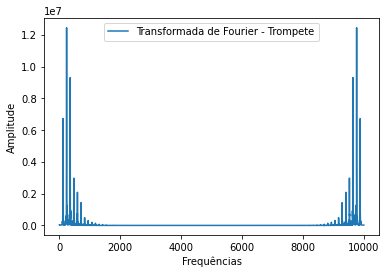

In [ ]:
%%time
# Basicamente, iremos utilizar o código feito para o data4 para calcular a DFT do data5. Vamos então ter o seguinte:

# De forma a obter os primeiros 10000 elementos precisamos de reduzir o tamanho do data5

#index = range(10000,100000,1)
# data5m = np.delete(data5,index)
                                    # as duas linhas acima e a linha de código a seguir são duas formas de obter os primeiros 10000 elementos
data5m = data5[0:10000]

# Aplicação da função DFT_slow no data4 já reduzido
a = abs (DFT_slow(data5m))

# Construção do gráfico da transformada do data5 reduzido
plt.xlabel('Frequências')
plt.ylabel('Amplitude')
plt.plot(a,label='Transformada de Fourier - Trompete')
plt.legend()

Wall time: 48.3 ms


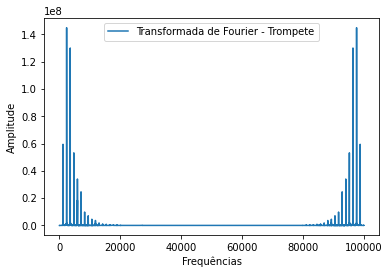

In [ ]:
%%time
# Tal como fizemos no data4, agora também iremos utilizar o método FFT para calcular a transformada:
b = abs (np.fft.fft(data5))

# Construção do gráfico da transformada do data5
plt.xlabel('Frequências')
plt.ylabel('Amplitude')
plt.plot(b,label='Transformada de Fourier - Trompete')
plt.legend()

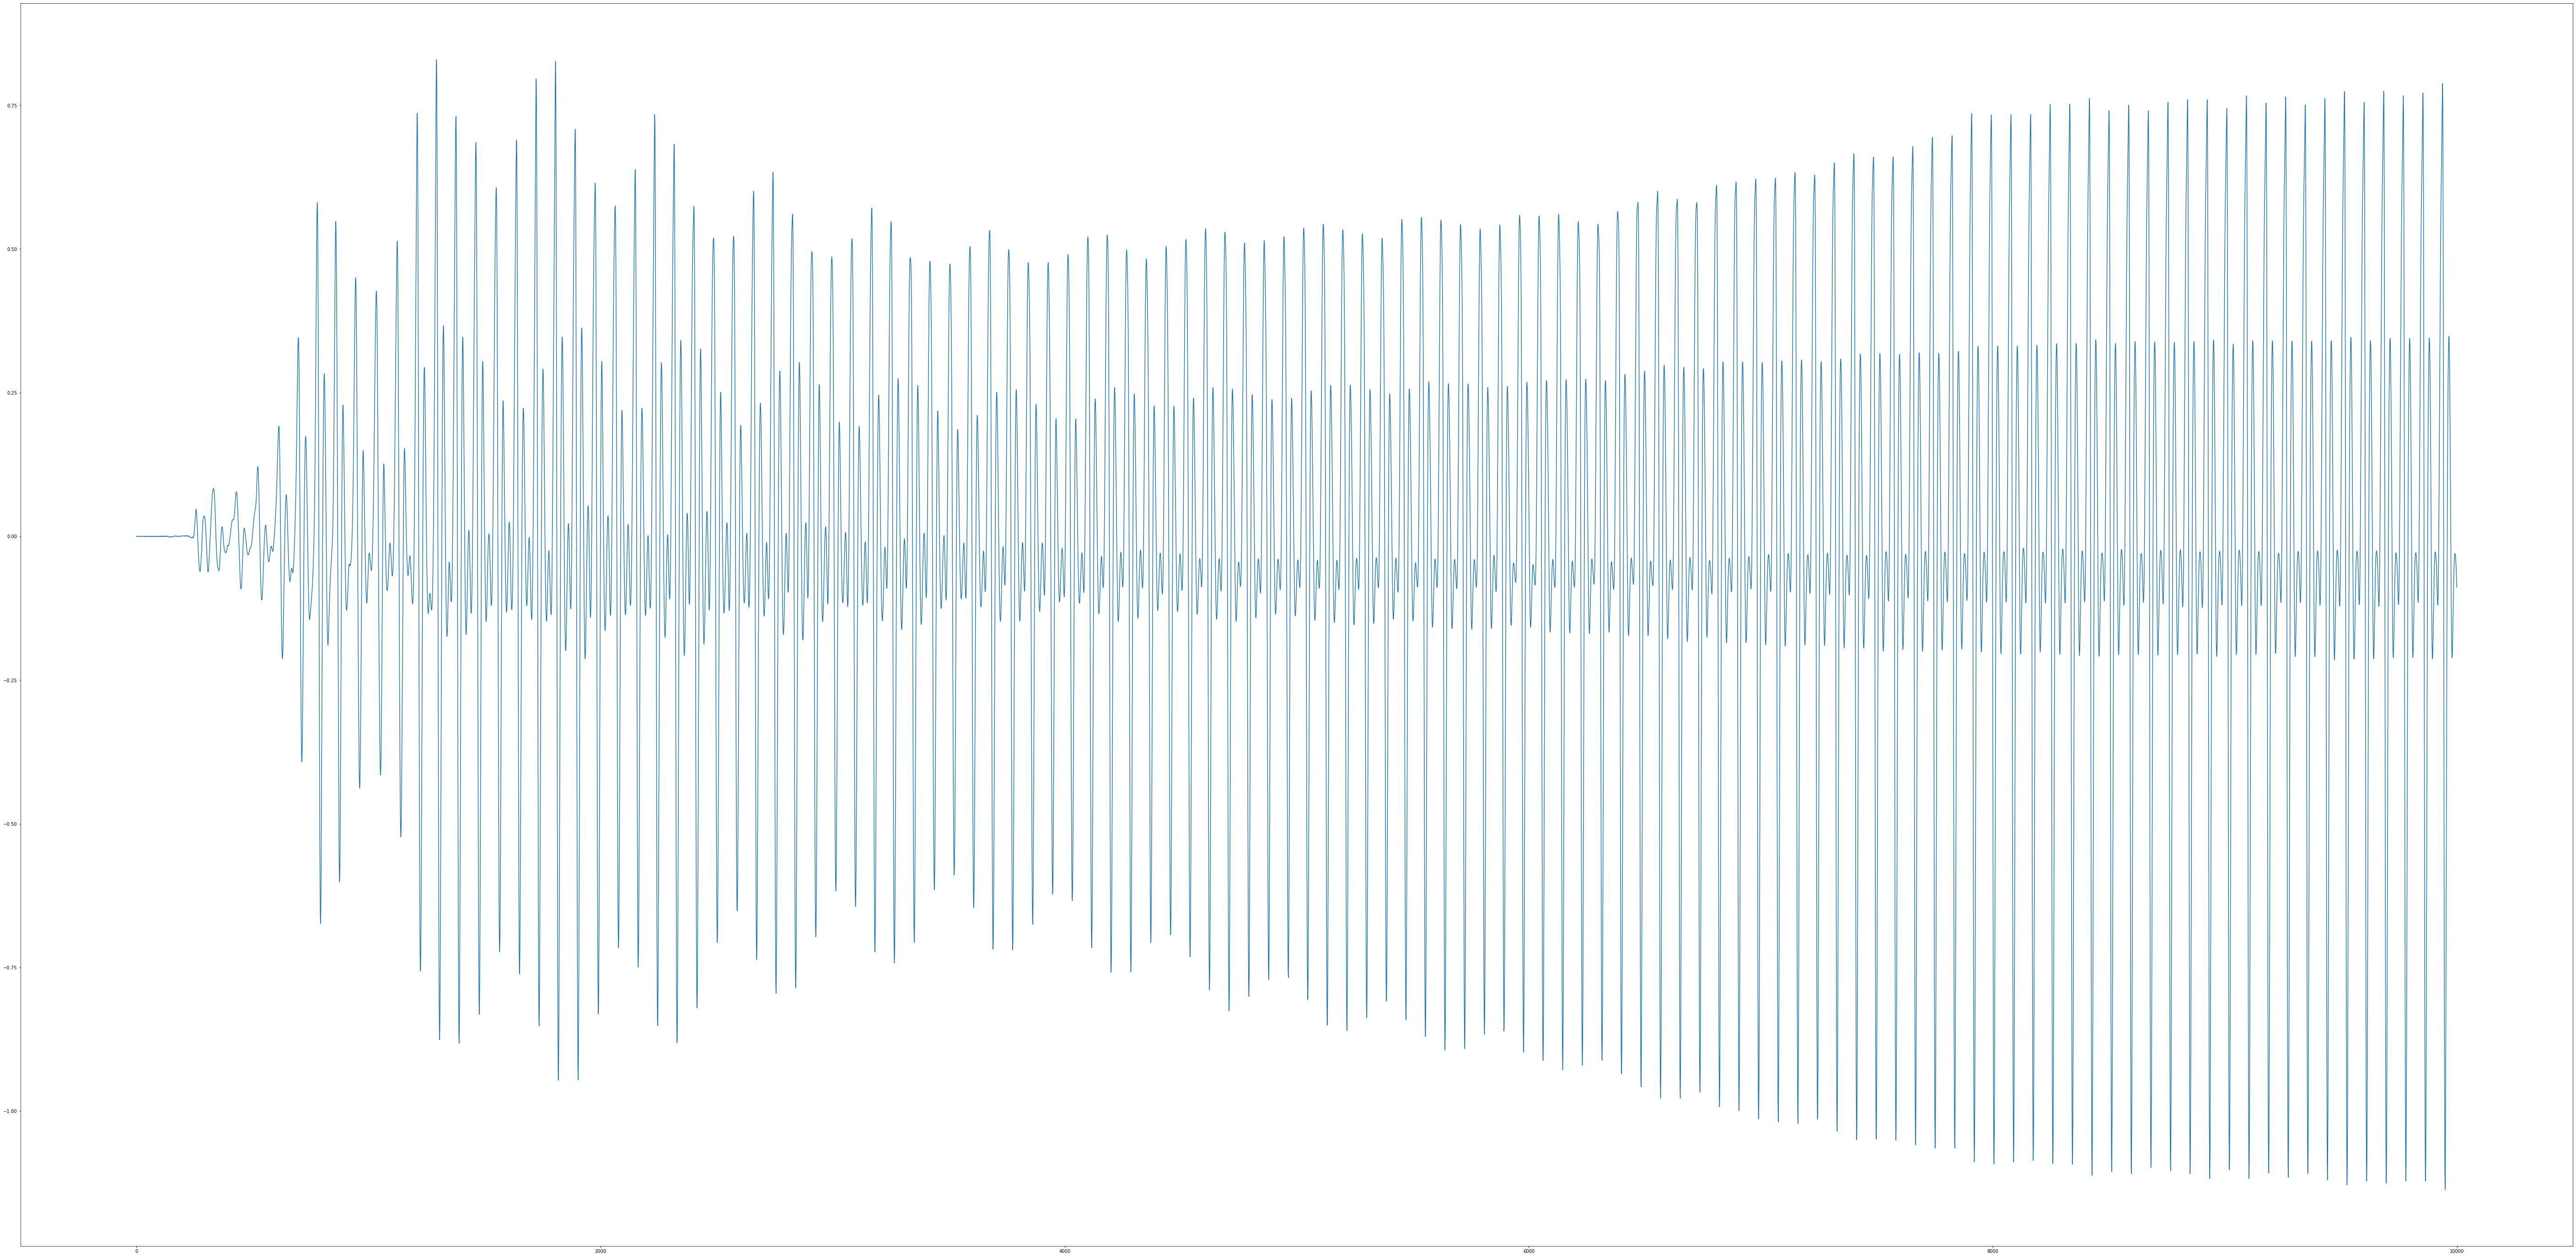

In [ ]:
# calculando agora os coeficientes da série de Fourier correspondente vamos ter o seguinte:
y2=np.fft.rfft(data5m)/10000
plt.figure(figsize=[100,50])
plt.plot(np.fft.irfft(y2))

### Discussão de Resultados:

-  Tendo em conta os tempos de execução utilizando as funções "DFT_slow()" e a FFT predefinida "np.fft.fft()", é percetível que em termos de eficiência prevalece consideravelmente a última, fruto da dimensão de valores colocados em input nestas funções (10000).

-  Sabemos que, por definição, que metade da frequência de amostragem tem que ser maior que as frequências obtidas.

In [ ]:
# Como N=10000 e f_0 é igual a 44,1kHz vamos ter que:
N = 10000   # número de amostras
f0 = 44100  # frequência de amostragem
f = (1/N) * f0
print(f)

4.41


In [ ]:
# Cálculo da frequência da nota do piano:
imax = np.argmax(y1)   # utilizando a função np.argmax obtemos o índice do primeiro elemento com maior amplitude
print(imax)

f1 = imax*f   # cálculo da frequência da nota
print(f1)

119
524.79


In [ ]:
# Cálculo da frequência da nota do trompete:
imax = np.argmax(y2) # utilizando a função np.argmax obtemos o índice do primeiro elemento com maior amplitude
print(imax)

f2 = imax*f   # cálculo da frequência da nota
print(f2)

354
1561.14


Sendo que a frequência da nota do piano e do trompete deu 524.79 Hz e 1561.14Hz, respetivamente, temos que as notas tocadas por cada instrumento é: Dó em 5ª oitava (tocada pelo piano); Fá# em 6ª oitava (tocada pelo trompete).

(verificamos isto através deste site: https://pages.mtu.edu/~suits/notefreqs.html)

-  Verificamos nos gráficos das transformadas de Fourier que o trompete tem mais "picos", ou seja, mais harmónicos que o piano. Ora, com isto podemos explicar através do facto de que o piano é um instrumento mais puro por ser de corda, onde o ruído é mais facilmente controlado que num instrumento de sopro como o Trompete.